# Massachusetts MAUP Cleaning Notebook

This notebook prepares the Massachusetts precinct data for the project analysis. It keeps the MAUP steps together, saves the cleaned shapefile, saves the election-column config, and creates the manually connected dual graph information used later in `analysis.ipynb`.


In [1]:
# setup and imports
import sys
!{sys.executable} -m pip install --only-binary=:all: "maup>=1.1.0" numpy pandas geopandas gerrychain matplotlib

import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import networkx as nx

import maup
from maup import smart_repair

import gerrychain
from gerrychain import Graph, GeographicPartition, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.constraints import contiguous

warnings.filterwarnings("ignore")
maup.progress.enabled = True



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\modya\anaconda3\python.exe -m pip install --upgrade pip


## Data sources

The three files below are the files used for the project stack: 2020 block population, 2024 Massachusetts precinct election results, and 2020 Massachusetts counties. Run the notebook from the folder that contains these downloaded data folders.


In [2]:
# file paths
population_path = os.path.join("ma_pl2020_b", "ma_pl2020_p1_b.shp")
election_path = os.path.join("ma_2024_gen_prec", "ma_2024_gen_all_prec", "ma_2024_gen_all_prec.shp")
county_path = os.path.join("ma_pl2020_cnty", "ma_pl2020_cnty.shp")

for label, path in {
    "population": population_path,
    "election": election_path,
    "county": county_path,
}.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find the {label} file at: {path}")

# load data
pop_df = gpd.read_file(population_path)
county_df = gpd.read_file(county_path)
elec_df = gpd.read_file(election_path)

print("population rows:", len(pop_df))
print("county rows:", len(county_df))
print("election rows:", len(elec_df))


population rows: 107278
county rows: 14
election rows: 2383


In [3]:
# election columns used later in the analysis notebook
DEM_COL_1 = "G24PREDHAR"   # 2024 President - Harris (Democrat)
REP_COL_1 = "G24PRERTRU"   # 2024 President - Trump (Republican)
DEM_COL_2 = "G24USSDWAR"   # 2024 US Senate - Warren (Democrat)
REP_COL_2 = "G24USSRDEA"   # 2024 US Senate - Deaton (Republican)

election_cols = [DEM_COL_1, REP_COL_1, DEM_COL_2, REP_COL_2]
missing_cols = [col for col in election_cols if col not in elec_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected election columns: {missing_cols}")

# make sure vote columns are numeric before any aggregation later
for col in election_cols:
    elec_df[col] = pd.to_numeric(elec_df[col], errors="coerce").fillna(0)

print("Election columns checked:", election_cols)


Election columns checked: ['G24PREDHAR', 'G24PRERTRU', 'G24USSDWAR', 'G24USSRDEA']


In [4]:
# move everything to one projected CRS before running MAUP repairs
utm_crs = elec_df.estimate_utm_crs()

pop_df = pop_df.to_crs(utm_crs)
county_df = county_df.to_crs(utm_crs)
elec_df = elec_df.to_crs(utm_crs)

print("population CRS:", pop_df.crs)
print("county CRS:", county_df.crs)
print("election CRS:", elec_df.crs)

print("population doctor:", maup.doctor(pop_df))
print("county doctor:", maup.doctor(county_df))
print("election doctor:", maup.doctor(elec_df))


population CRS: EPSG:32619
county CRS: EPSG:32619
election CRS: EPSG:32619


100%|█████████████████████████████████████████████████████████████████████████| 107278/107278 [07:12<00:00, 247.77it/s]


population doctor: True


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 37.96it/s]


county doctor: True


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:16<00:00, 148.26it/s]


There are 519 overlaps.
There are 77 holes.
There are some invalid geometries.
election doctor: False


## Repair precinct geometry

The course default snap precision is 10, so the notebook tries that first. If that leaves unresolved MAUP topology problems, the code falls back to 8 and prints the reason. The fallback is not arbitrary: a smaller snap precision rounds slightly more, which can fix near-coincident precinct/county boundaries that otherwise remain as tiny slivers or holes. The population check later is still the main guardrail that we did not lose population during the cleaning step.


In [5]:
# repair precincts inside counties and fix tiny rook boundaries
min_rook_length = 30  # meters; borders shorter than this are treated as point contacts
snap_precision_used = None
snap_precision_reason = ""


def repair_with_snap(snap_precision):
    return smart_repair(
        elec_df,
        nest_within_regions=county_df,
        min_rook_length=min_rook_length,
        snap_precision=snap_precision,
    )

start = time.time()
try:
    final_df = repair_with_snap(10)
    doctor_ok = maup.doctor(final_df)
    if doctor_ok:
        snap_precision_used = 10
        snap_precision_reason = "Used the class default snap precision of 10."
    else:
        print("snap_precision=10 ran, but maup.doctor did not return True. Trying snap_precision=8.")
        final_df = repair_with_snap(8)
        doctor_ok = maup.doctor(final_df)
        snap_precision_used = 8
        snap_precision_reason = (
            "Used snap_precision=8 because snap_precision=10 left unresolved topology issues. "
            "The lower precision snaps near-coincident precinct/county boundaries a little more aggressively."
        )
except Exception as err:
    print("snap_precision=10 failed with this error:")
    print(err)
    print("Trying snap_precision=8 instead.")
    final_df = repair_with_snap(8)
    doctor_ok = maup.doctor(final_df)
    snap_precision_used = 8
    snap_precision_reason = (
        "Used snap_precision=8 because snap_precision=10 failed during smart_repair. "
        "The lower precision is a reasonable fallback for tiny boundary mismatches."
    )

print("repair runtime (seconds):", round(time.time() - start, 2))
print("snap precision used:", snap_precision_used)
print(snap_precision_reason)
print("final doctor:", doctor_ok)

if not doctor_ok:
    print("maup.doctor is still not True. Check the MAUP output above and explain any remaining hole/sliver in the report.")


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 38.68it/s]


Snapping all geometries to a grid with precision 10^( -5 ) to avoid GEOS errors.
snap_precision=10 failed with this error:
TopologyException: Iterated noding failed to converge after 10 iterations (near 346903 4.6408e+06)
Trying snap_precision=8 instead.


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 31.76it/s]


Snapping all geometries to a grid with precision 10^( -3 ) to avoid GEOS errors.


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00,  7.09it/s]


...

2 gaps in region 13 will remain unfilled, because they exceed the area threshold.


Gaps to fill in region 13: 100%|███████████████████████████████████████████████████████| 30/30 [00:05<00:00,  5.88it/s]


Converting small rook adjacencies to queen...


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:14<00:00, 161.33it/s]


repair runtime (seconds): 806.25
snap precision used: 8
Used snap_precision=8 because snap_precision=10 failed during smart_repair. The lower precision is a reasonable fallback for tiny boundary mismatches.
final doctor: True


In [6]:
# assign 2020 blocks to cleaned precincts and add total population
precinct_assignments = maup.assign(pop_df.geometry, final_df.geometry)

population_by_precinct = pop_df["P0010001"].groupby(precinct_assignments).sum()
final_df["TOTPOP"] = population_by_precinct.reindex(final_df.index).fillna(0).astype(int)

# population check: block total must equal precinct total
block_pop = int(pop_df["P0010001"].sum())
precinct_pop = int(final_df["TOTPOP"].sum())
assert block_pop == precinct_pop, f"Population mismatch: blocks={block_pop}, precincts={precinct_pop}"
print(f"Population check passed: {block_pop:,} == {precinct_pop:,}")

# clean district labels so the analysis notebook gets stable district names
raw_cd = final_df["CONG_DIST"].astype(str).str.strip()
digit_cd = raw_cd.str.extract(r"(\d+)")[0]
final_df["CD"] = digit_cd.fillna(raw_cd).str.zfill(2)

# keep vote columns numeric after the repair as well
for col in election_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce").fillna(0)

# save shapefile and config
outdir = "MA"
os.makedirs(outdir, exist_ok=True)
shape_path = os.path.join(outdir, "MA.shp")
final_df.to_file(shape_path)

config = {
    "DEM_COL_1": DEM_COL_1,
    "REP_COL_1": REP_COL_1,
    "DEM_COL_2": DEM_COL_2,
    "REP_COL_2": REP_COL_2,
    "snap_precision_used": snap_precision_used,
    "snap_precision_reason": snap_precision_reason,
    "min_rook_length": min_rook_length,
}
with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved cleaned shapefile to:", shape_path)
print("Saved config.json")
print("number of districts:", final_df["CD"].nunique())
print("districts:", sorted(final_df["CD"].dropna().unique()))


100%|██████████████████████████████████████████████████████████████████████████████| 2383/2383 [01:03<00:00, 37.39it/s]


Population check passed: 7,029,917 == 7,029,917
Saved cleaned shapefile to: MA\MA.shp
Saved config.json
number of districts: 9
districts: ['01', '02', '03', '04', '05', '06', '07', '08', '09']


In [7]:
# quick column check for the cleaned file
print(final_df.columns.tolist())


['UNIQUE_ID', 'COUNTYFP', 'City/Town', 'Ward', 'Pct', 'County', 'CONG_DIST', 'SLDL_DIST', 'SLDU_DIST', 'G24PREDHAR', 'G24PRELOLI', 'G24PREOOTH', 'G24PRERTRU', 'G24PREUAYY', 'G24PREUCRU', 'G24PREUSON', 'G24PREUSTE', 'G24PREUWES', 'G24USSDWAR', 'G24USSOOTH', 'G24USSRDEA', 'GCON01DNEA', 'GCON01OOTH', 'GCON01UMIL', 'GCON02DMCG', 'GCON02OOTH', 'GCON02USHE', 'GCON03DTRA', 'GCON03OOTH', 'GCON04DAUC', 'GCON04OOTH', 'GCON04UFAD', 'GCON05DCLA', 'GCON05OOTH', 'GCON06DMOU', 'GCON06OOTH', 'GCON07DPRE', 'GCON07OOTH', 'GCON08DLYN', 'GCON08OOTH', 'GCON08RBUR', 'GCON09DKEA', 'GCON09OOTH', 'GCON09RSUL', 'GSLB01DLOU', 'GSLB01OOTH', 'GSLB01RCHA', 'GSLB02DHAW', 'GSLB02OOTH', 'GSLB02UBEL', 'GSLB02WNEL', 'GSLB03DDOH', 'GSLB03OOTH', 'GSLB04OOTH', 'GSLB04RHOW', 'GSLB05DHAD', 'GSLB05OOTH', 'GSLB05RTHU', 'GSLB06DFIO', 'GSLB06OOTH', 'GSLB07DSIL', 'GSLB07OOTH', 'GSLB08DOUE', 'GSLB08OOTH', 'GSLB08RTHR', 'GSLB08UGEL', 'GSLB08UHAD', 'GSLB08USOA', 'GSLB09DMAR', 'GSLB09OOTH', 'GSLB10DSYL', 'GSLB10OOTH', 'GSLB10RPIR', '

## Create the connected dual graph information

Some Massachusetts districts include islands or disconnected land pieces. The shapefile can be geographically correct while the dual graph is not connected in the way GerryChain needs. This section connects the nearest disconnected pieces inside each current district, saves those added dual-graph edges, and makes a zoomed verification image.


In [8]:
# build the dual graph from the cleaned shapefile
ma_graph = Graph.from_file(
    shape_path,
    adjacency="queen",
    cols_to_add=["TOTPOP", "CD", DEM_COL_1, REP_COL_1, DEM_COL_2, REP_COL_2],
)

# use the same dataframe index as the graph node labels
map_df = gpd.read_file(shape_path)
map_df.index = list(ma_graph.nodes())

# make the district labels consistent on both the graph and dataframe
for v in ma_graph.nodes():
    ma_graph.nodes[v]["CD"] = str(ma_graph.nodes[v]["CD"]).zfill(2)
map_df["CD"] = map_df["CD"].astype(str).str.zfill(2)

initial_plan = {v: ma_graph.nodes[v]["CD"] for v in ma_graph.nodes()}
print("Graph connected before manual dual edges?", nx.is_connected(ma_graph))

# add the nearest centroid-to-centroid connection inside any district that is disconnected
# this is only changing the dual graph for GerryChain, not the district map geometry
temp_graph = nx.Graph(ma_graph)
centroids = map_df.geometry.centroid
added_edges = []

for district_label in sorted(set(initial_plan.values())):
    district_nodes = [v for v in temp_graph.nodes() if initial_plan[v] == district_label]
    district_graph = temp_graph.subgraph(district_nodes)

    while len(district_nodes) > 0 and not nx.is_connected(district_graph):
        components = sorted(nx.connected_components(district_graph), key=len, reverse=True)
        main_component = list(components[0])
        other_component = list(components[1])

        best_u = None
        best_v = None
        best_dist = float("inf")

        for u in main_component:
            for v in other_component:
                dist = centroids.loc[u].distance(centroids.loc[v])
                if dist < best_dist:
                    best_dist = dist
                    best_u = u
                    best_v = v

        temp_graph.add_edge(best_u, best_v)
        added_edges.append({
            "u": best_u,
            "v": best_v,
            "CD": district_label,
            "distance_m": round(float(best_dist), 2),
        })
        print(
            "added edge in district", district_label,
            "between", best_u, "and", best_v,
            "distance", round(float(best_dist), 2), "meters"
        )

        district_graph = temp_graph.subgraph(district_nodes)

connected_graph = gerrychain.Graph(temp_graph)

# save the added edges so analysis.ipynb can rebuild the same connected graph without rerunning this search
added_edges_path = os.path.join(outdir, "MA_added_edges.csv")
pd.DataFrame(added_edges, columns=["u", "v", "CD", "distance_m"]).to_csv(added_edges_path, index=False)
print("Saved added-edge list to:", added_edges_path)

# also try to save the full connected graph as a JSON, when the installed GerryChain version supports it
connected_graph_json = os.path.join(outdir, "MA_connected_graph.json")
try:
    connected_graph.to_json(connected_graph_json)
    print("Saved connected graph JSON to:", connected_graph_json)
except Exception as err:
    print("Could not save Graph JSON. The CSV of added edges was saved and is enough for analysis.ipynb.")
    print(err)

# verify contiguity with the connected graph
elections = [
    Election("PRES24", {"Democratic": DEM_COL_1, "Republican": REP_COL_1}),
    Election("SEN24",  {"Democratic": DEM_COL_2, "Republican": REP_COL_2}),
]
updaters = {
    "cut_edges": cut_edges,
    "district population": Tally("TOTPOP", alias="district population"),
}
updaters.update({election.name: election for election in elections})

initial_partition = GeographicPartition(
    connected_graph,
    assignment=initial_plan,
    updaters=updaters,
)

print("Graph connected after manual dual edges?", nx.is_connected(connected_graph))
print("Initial partition contiguous after manual dual edges?", contiguous(initial_partition))


Graph connected before manual dual edges? False
added edge in district 07 between 629 and 199 distance 648.58 meters
added edge in district 08 between 1701 and 264 distance 1210.47 meters
added edge in district 08 between 427 and 385 distance 1310.3 meters
added edge in district 08 between 436 and 191 distance 4343.66 meters
added edge in district 09 between 830 and 2064 distance 10714.75 meters
added edge in district 09 between 669 and 924 distance 13653.45 meters
added edge in district 09 between 773 and 1447 distance 40816.46 meters
Saved added-edge list to: MA\MA_added_edges.csv
Saved connected graph JSON to: MA\MA_connected_graph.json
Graph connected after manual dual edges? True
Initial partition contiguous after manual dual edges? True


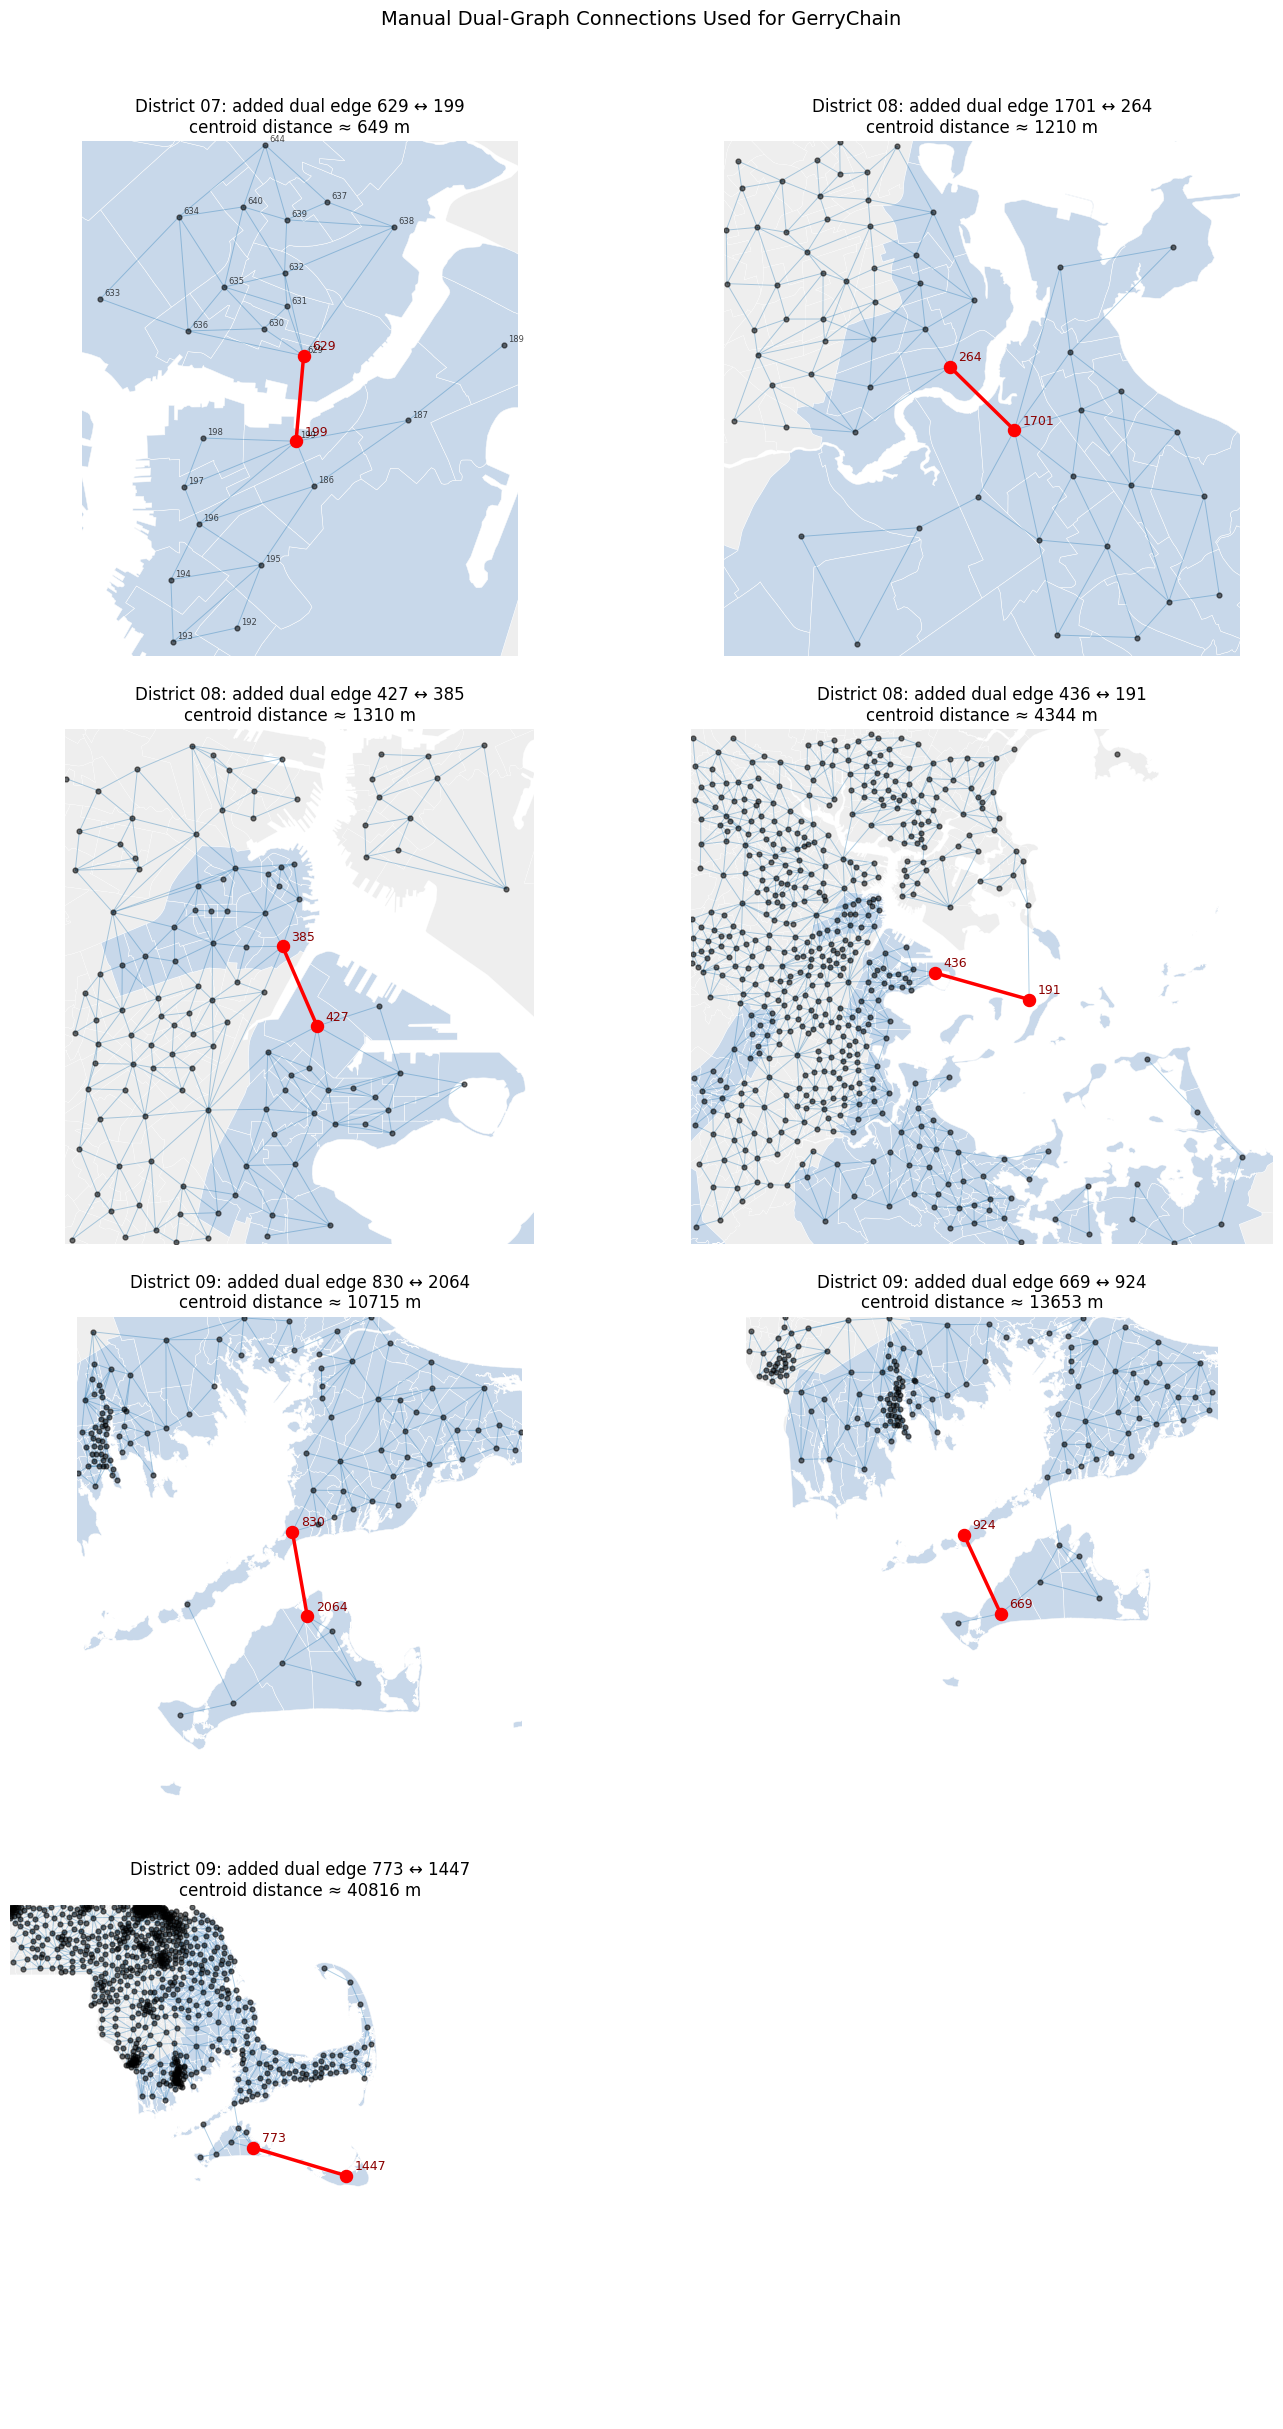

Added edges:
{'u': 629, 'v': 199, 'CD': '07', 'distance_m': 648.58}
{'u': 1701, 'v': 264, 'CD': '08', 'distance_m': 1210.47}
{'u': 427, 'v': 385, 'CD': '08', 'distance_m': 1310.3}
{'u': 436, 'v': 191, 'CD': '08', 'distance_m': 4343.66}
{'u': 830, 'v': 2064, 'CD': '09', 'distance_m': 10714.75}
{'u': 669, 'v': 924, 'CD': '09', 'distance_m': 13653.45}
{'u': 773, 'v': 1447, 'CD': '09', 'distance_m': 40816.46}


In [9]:
# zoomed dual-graph visualization of the added connections
# gray lines = nearby dual graph edges, black dots = centroids of nearby precinct nodes, red = manual connection
if len(added_edges) == 0:
    print("No manual dual-graph edges were needed.")
else:
    ncols = min(2, len(added_edges))
    nrows = int(np.ceil(len(added_edges) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, edge_info in zip(axes, added_edges):
        u = edge_info["u"]
        v = edge_info["v"]
        district_label = edge_info["CD"]
        dist = edge_info["distance_m"]

        district_df = map_df[map_df["CD"] == district_label]
        cu = centroids.loc[u]
        cv = centroids.loc[v]

        # zoom to the two connected pieces with a practical minimum padding
        pad = max(float(dist) * 2.5, 1200)
        xmin = min(cu.x, cv.x) - pad
        xmax = max(cu.x, cv.x) + pad
        ymin = min(cu.y, cv.y) - pad
        ymax = max(cu.y, cv.y) + pad

        nearby_nodes = [
            node for node, point in centroids.items()
            if xmin <= point.x <= xmax and ymin <= point.y <= ymax
        ]

        map_df.plot(ax=ax, color="#eeeeee", edgecolor="white", linewidth=0.2)
        district_df.plot(ax=ax, color="#c8d8ea", edgecolor="white", linewidth=0.35)

        # draw nearby dual edges between centroids
        nearby_set = set(nearby_nodes)
        lines = []
        for a, b in temp_graph.edges():
            if a in nearby_set and b in nearby_set:
                ca = centroids.loc[a]
                cb = centroids.loc[b]
                lines.append([(ca.x, ca.y), (cb.x, cb.y)])
        if lines:
            ax.add_collection(LineCollection(lines, linewidths=0.7, alpha=0.35))

        # show centroids near the district/connection
        nearby_centroids = gpd.GeoSeries([centroids.loc[node] for node in nearby_nodes], crs=map_df.crs)
        nearby_centroids.plot(ax=ax, markersize=12, color="black", alpha=0.55, zorder=4)

        # highlight the manual edge and endpoints
        ax.plot([cu.x, cv.x], [cu.y, cv.y], color="red", linewidth=2.5, zorder=6)
        ax.scatter([cu.x, cv.x], [cu.y, cv.y], s=75, color="red", zorder=7)
        ax.annotate(str(u), (cu.x, cu.y), textcoords="offset points", xytext=(6, 4), fontsize=9, color="darkred")
        ax.annotate(str(v), (cv.x, cv.y), textcoords="offset points", xytext=(6, 4), fontsize=9, color="darkred")

        # label all nearby nodes only when it is not too cluttered
        if len(nearby_nodes) <= 35:
            for node in nearby_nodes:
                c = centroids.loc[node]
                ax.annotate(str(node), (c.x, c.y), textcoords="offset points", xytext=(3, 2), fontsize=6, alpha=0.7)

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_title(f"District {district_label}: added dual edge {u} ↔ {v}\ncentroid distance ≈ {float(dist):.0f} m")
        ax.set_axis_off()

    for ax in axes[len(added_edges):]:
        ax.set_visible(False)

    plt.suptitle("Manual Dual-Graph Connections Used for GerryChain", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "island_connections.png"), dpi=150, bbox_inches="tight")
    plt.show()

print("Added edges:")
for edge_info in added_edges:
    print(edge_info)


#### final cleaning summary
print("STACK SUMMARY")
print("precinct file used:", election_path)
print("population file used:", population_path)
print("county file used:", county_path)
print("doctor after repair:", maup.doctor(final_df))  
print("snap precision used:", snap_precision_used)
print("min rook length:", min_rook_length)
print("total population in blocks:", block_pop)
print("total population in final precincts:", precinct_pop)
print("number of districts:", final_df["CD"].nunique())
print("manual dual-graph edges added:", len(added_edges))
print("graph connected after manual edges:", nx.is_connected(connected_graph))
print("initial partition contiguous after manual edges:", contiguous(initial_partition))


In [11]:
#### final cleaning summary
print("STACK SUMMARY")
print("precinct file used:", election_path)
print("population file used:", population_path)
print("county file used:", county_path)
print("doctor after repair:", maup.doctor(final_df))  
print("snap precision used:", snap_precision_used)
print("min rook length:", min_rook_length)
print("total population in blocks:", block_pop)
print("total population in final precincts:", precinct_pop)
print("number of districts:", final_df["CD"].nunique())
print("manual dual-graph edges added:", len(added_edges))
print("graph connected after manual edges:", nx.is_connected(connected_graph))
print("initial partition contiguous after manual edges:", contiguous(initial_partition))


STACK SUMMARY
precinct file used: ma_2024_gen_prec\ma_2024_gen_all_prec\ma_2024_gen_all_prec.shp
population file used: ma_pl2020_b\ma_pl2020_p1_b.shp
county file used: ma_pl2020_cnty\ma_pl2020_cnty.shp


100%|█████████████████████████████████████████████████████████████████████████████| 2383/2383 [00:17<00:00, 137.41it/s]


doctor after repair: True
snap precision used: 8
min rook length: 30
total population in blocks: 7029917
total population in final precincts: 7029917
number of districts: 9
manual dual-graph edges added: 7
graph connected after manual edges: True
initial partition contiguous after manual edges: True
